<a href="https://colab.research.google.com/github/rxphaelbihag/Data-Analysis-with-R/blob/main/Predicting_Disposal_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicting Disposal Method

---

## Introduction
**Goal**: Predicting DisposalMethod (Composting, Recycling, Landfill, or Combination

**Predictors**:
- **UsingPlasticProducts**: How often the participant uses plastic products (Often, Sometimes, or Rarely).
- **SustainableBrands**: Whether the participant prioritizes purchasing from sustainable brands (True or False)
- **Location**: The location of the participant (Urban, Suburban, or Rural).
- **TransportationMode**: The primary mode of transportation used by the participant (Bike, Public Transit, Car, or Walk)

---


## Data Wrangling
In this section, we will be working with our dataset to prepare it for modeling. We will be importing the dataset from Kaggle, extracting the necessary columns/features, and essentially making it manageable.

### Importing Dataset from Kaggle and Necessary Libraries

In [1]:
# To make downloading the libraries faster
download.file("https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_focal.sh",
              "add_cranapt_focal.sh")
Sys.chmod("add_cranapt_focal.sh", "0755")
system("./add_cranapt_focal.sh")

# Import the necessary packages
library(tidyverse)
library(nnet)

install.packages("caret")
library(caret)

install.packages("lmtest")
library(lmtest)

install.packages("DescTools")
library(DescTools)

install.packages("car")
library(car)

install.packages("Hmisc")
library(Hmisc)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: lattice


Attaching package: ‘care

In [2]:
# Kaggle credentials Set Up Directly into the code
Sys.setenv(KAGGLE_USERNAME = "raphaelkhandiebihag")
Sys.setenv(KAGGLE_KEY = "KGAT_71b38028c84a05aab1dfb918cd8e716b")

# Install the Kaggle CLI tool
system("pip install kaggle --upgrade --quiet", wait = TRUE)

# Download the dataset
system("kaggle datasets download naveennas/sustainable-lifestyle-rating-dataset", wait = TRUE)

# Unzip the downloaded file
system("unzip sustainable-lifestyle-rating-dataset.zip -d dataset", wait = TRUE)

In [3]:
# Import the dataset
sustainability_data <- read_csv("/content/dataset/lifestyle_sustainability_data.csv")
head(sustainability_data)

Rows: 499 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): Location, DietType, LocalFoodFrequency, TransportationMode, Energy...
dbl  (7): ParticipantID, Age, HomeSize, EnvironmentalAwareness, MonthlyElect...
lgl  (1): SustainableBrands

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<lgl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,TRUE,5,High,100,1500,Female,Rarely,Composting,High,5
2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,TRUE,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,FALSE,2,Low,400,4500,Male,Often,Landfill,Low,1
4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,TRUE,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,TRUE,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3
6,58,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2200,Always,FALSE,1,None,450,5000,Male,Often,Landfill,None,1


### Creating a subset of the dataset

Since the dataset and has a lot of features, we will only be extracting the columns which we think are significant predictors for Disposal Method.

In [4]:
# Creating a subset
new_sustainability_data <- subset(sustainability_data,
                                  select = c(DisposalMethods,
                                  UsingPlasticProducts,
                                  SustainableBrands,
                                  Location, TransportationMode))
head(new_sustainability_data)

DisposalMethods,UsingPlasticProducts,SustainableBrands,Location,TransportationMode
<chr>,<chr>,<lgl>,<chr>,<chr>
Composting,Rarely,TRUE,Urban,Bike
Recycling,Sometimes,TRUE,Suburban,Public Transit
Landfill,Often,FALSE,Rural,Car
Recycling,Rarely,TRUE,Urban,Walk
Combination,Sometimes,TRUE,Suburban,Public Transit
Landfill,Often,FALSE,Rural,Car


In [5]:
summary(new_sustainability_data)

  DisposalMethods UsingPlasticProducts SustainableBrands      Location  
 Length   :499    Length   :499        Mode :logical     Length   :499  
 N.unique :  4    N.unique :  4        FALSE:236         N.unique :  3  
 N.blank  :  0    N.blank  :  0        TRUE :263         N.blank  :  0  
 Min.nchar:  8    Min.nchar:  5                          Min.nchar:  5  
 Max.nchar: 11    Max.nchar:  9                          Max.nchar:  8  
 TransportationMode
 Length   :499     
 N.unique :  4     
 N.blank  :  0     
 Min.nchar:  3     
 Max.nchar: 14     

There are four unique values for DisposalMethods (Composting, Recycling, Landfill, or Combination). For this session, we will only be using Composting, Recycling, and Landfill. So, let's trim down our working data to only having these three.

In [6]:
working_data <- new_sustainability_data %>%filter(DisposalMethods != "Combination")
summary(working_data)

  DisposalMethods UsingPlasticProducts SustainableBrands      Location  
 Length   :410    Length   :410        Mode :logical     Length   :410  
 N.unique :  3    N.unique :  4        FALSE:207         N.unique :  3  
 N.blank  :  0    N.blank  :  0        TRUE :203         N.blank  :  0  
 Min.nchar:  8    Min.nchar:  5                          Min.nchar:  5  
 Max.nchar: 10    Max.nchar:  9                          Max.nchar:  8  
 TransportationMode
 Length   :410     
 N.unique :  4     
 N.blank  :  0     
 Min.nchar:  3     
 Max.nchar: 14     

### Our Data

Let's have a look at the data we are working with through graphs.

In [7]:
# Prints counts, percentages, and frequencies for all variables
describe(working_data)

working_data 

 5  Variables      410  Observations
--------------------------------------------------------------------------------
DisposalMethods 
       n  missing distinct 
     410        0        3 
                                           
Value      Composting   Landfill  Recycling
Frequency         124        141        145
Proportion      0.302      0.344      0.354
--------------------------------------------------------------------------------
UsingPlasticProducts 
       n  missing distinct 
     410        0        4 
                                                  
Value          Never     Often    Rarely Sometimes
Frequency         88       138        89        95
Proportion     0.215     0.337     0.217     0.232
--------------------------------------------------------------------------------
SustainableBrands 
       n  missing distinct 
     410        0        2 
                      
Value      FALSE  TRUE
Frequency    207   203
Proportion 0.505 0.495
-------

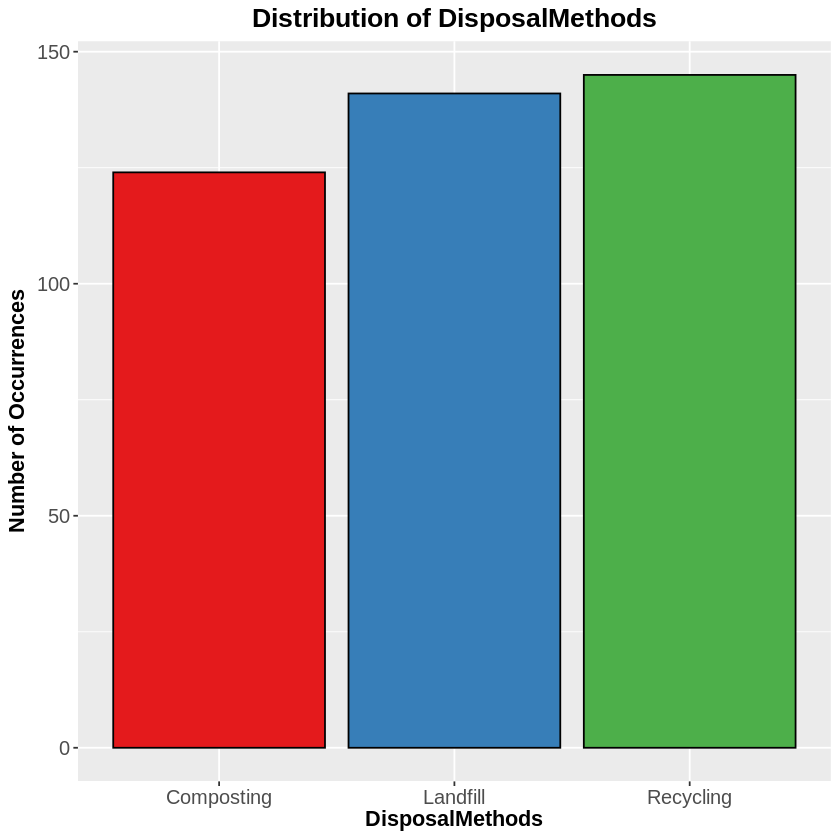

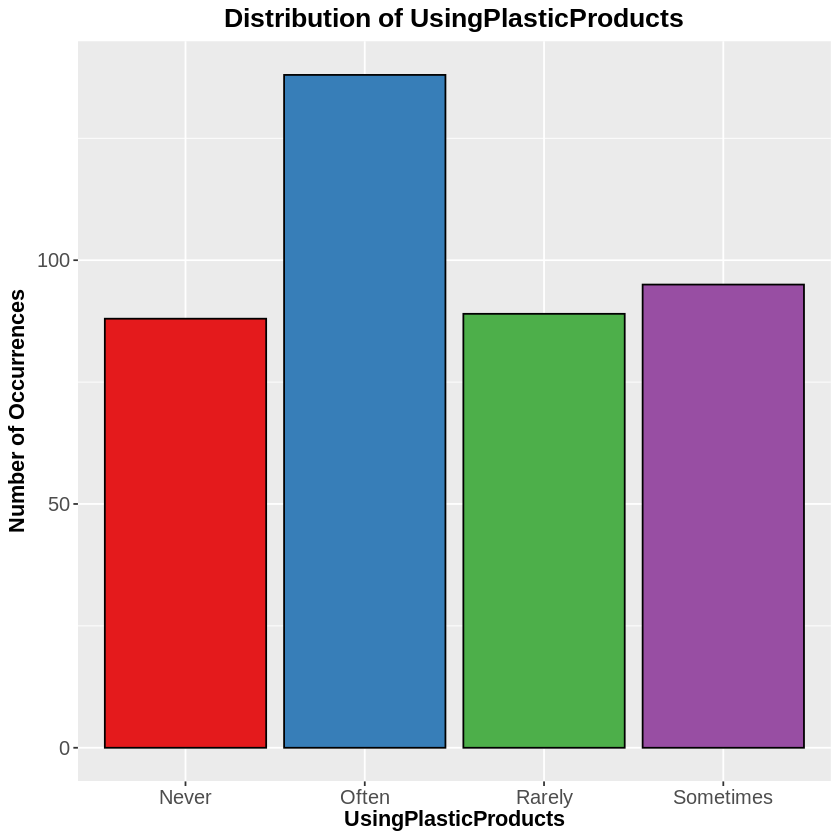

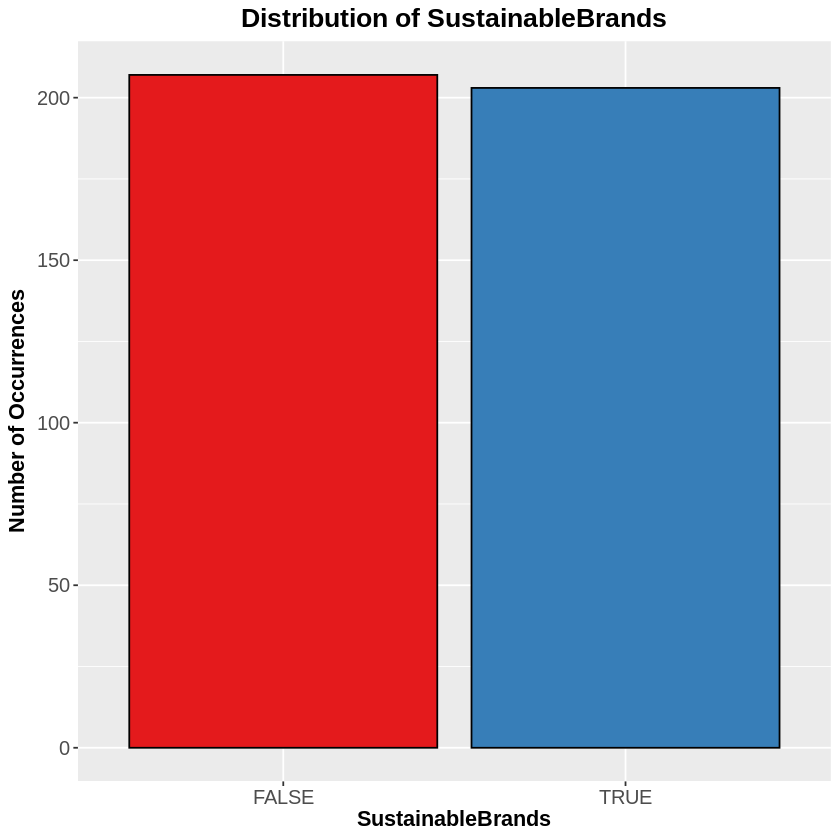

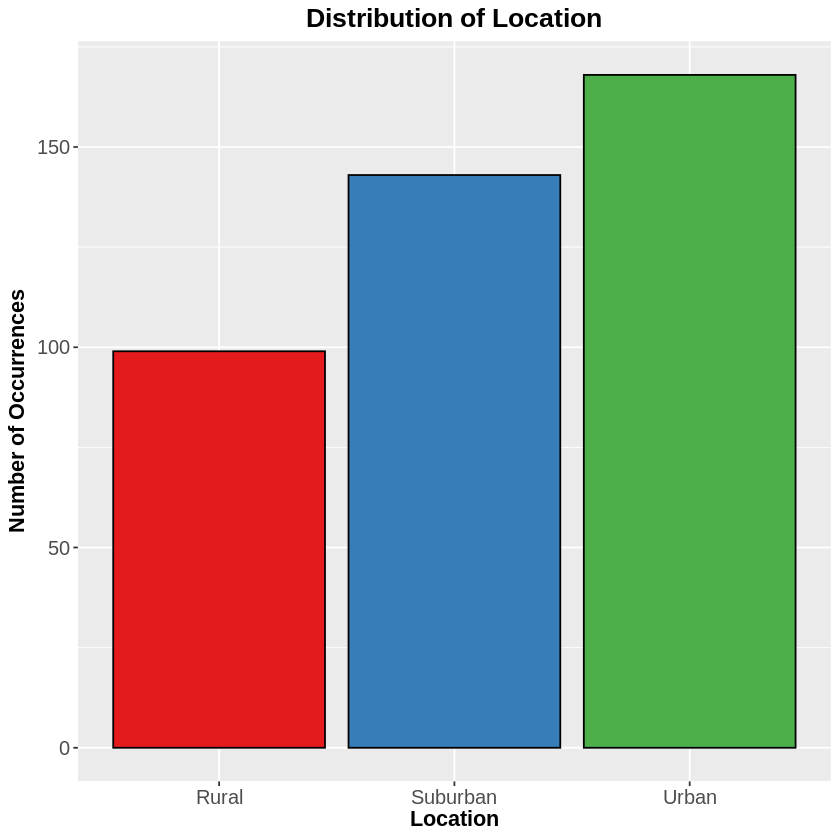

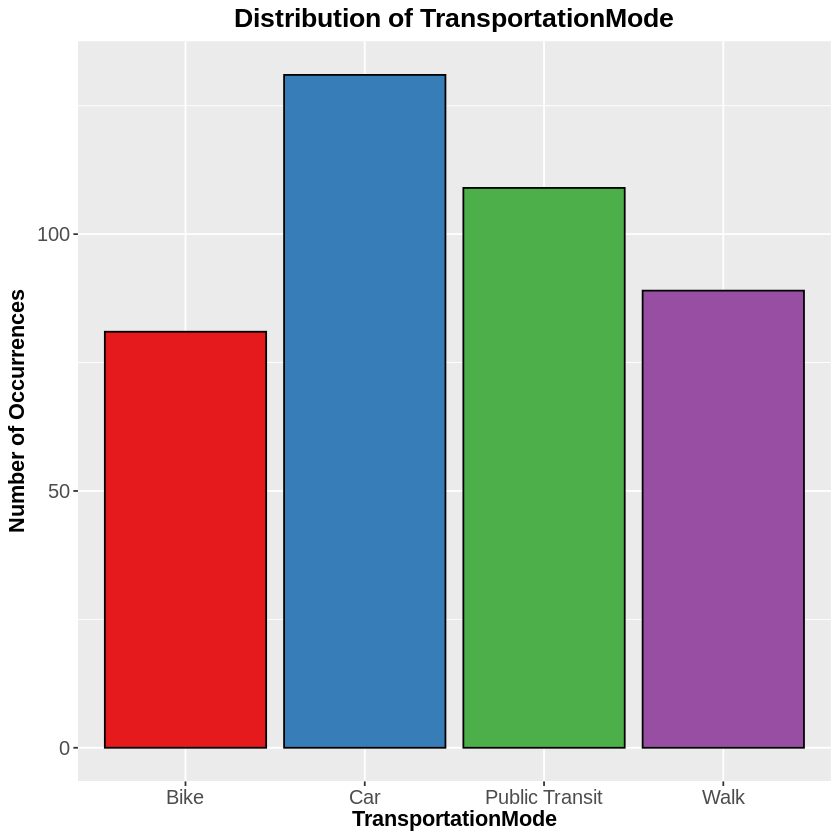

In [8]:
# For loop to plot all the features of the data
for (i in names(working_data)) {
    p <- ggplot(working_data, aes(x = .data[[i]], fill = .data[[i]])) +
        geom_bar(color = "black", show.legend = FALSE) +
        labs(
            title = paste("Distribution of", i),
            x = i,
            y = "Number of Occurrences"
        ) +
        scale_fill_brewer(palette = "Set1") +
       theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text = element_text(size = 12),
            axis.title = element_text(size = 13, face = "bold")
        )
    print(p)
}


### Proper Encoding and Releveling
Predictors such as SustainableBrands, UsingPlasticProducts, Location, Transportationmode, and DisposalMethods are in different data types. We'll have to turn them into factors so that they will be properly handled by the model.

After that, we have to set the baseline for the variables (releveling).



In [9]:
# DATA ENCODING: Converting the columns as factors
working_data$DisposalMethods <- as.factor(working_data$DisposalMethods)
working_data$UsingPlasticProducts <- as.factor(working_data$UsingPlasticProducts)
working_data$SustainableBrands <- as.factor(working_data$SustainableBrands)
working_data$Location <- as.factor(working_data$Location)
working_data$TransportationMode <- as.factor(working_data$TransportationMode)

head(working_data)

DisposalMethods,UsingPlasticProducts,SustainableBrands,Location,TransportationMode
<fct>,<fct>,<fct>,<fct>,<fct>
Composting,Rarely,TRUE,Urban,Bike
Recycling,Sometimes,TRUE,Suburban,Public Transit
Landfill,Often,FALSE,Rural,Car
Recycling,Rarely,TRUE,Urban,Walk
Landfill,Often,FALSE,Rural,Car
Composting,Never,TRUE,Urban,Bike


In [10]:
# RELEVELING

# Target Variable
working_data$DisposalMethods <- relevel(working_data$DisposalMethods, ref = "Recycling")

# Predictors:
working_data$UsingPlasticProducts <- relevel(working_data$UsingPlasticProducts, ref = "Sometimes")
working_data$SustainableBrands <- relevel(working_data$SustainableBrands, ref = "TRUE")
working_data$Location <- relevel(working_data$Location, ref = "Suburban")
working_data$TransportationMode <- relevel(working_data$TransportationMode, ref = "Car")

## Model Fitting

Now that the dataset is ready, we will begin model fitting. The choice for the model will be the Multinomial Logistic Regression. Our dependent variable is the Disposal Method and the predictors are UsingPlasticProducts, SustainableBrands, Location, and TransportationMode.

### Fitting the model

In [11]:
# Fit the model
model <- multinom(DisposalMethods ~ UsingPlasticProducts + SustainableBrands + Location + TransportationMode,
                  data = working_data, model=TRUE)

# View the raw coefficients and standard errors
summary <- summary(model)
summary

# weights:  33 (20 variable)
initial  value 450.431038 
iter  10 value 278.903050
iter  20 value 261.614185
final  value 261.605265 
converged


Call:
multinom(formula = DisposalMethods ~ UsingPlasticProducts + SustainableBrands + 
    Location + TransportationMode, data = working_data, model = TRUE)

Coefficients:
           (Intercept) UsingPlasticProductsNever UsingPlasticProductsOften
Composting  -0.9591694                  3.121073                 0.4625921
Landfill    -2.3640266                  2.123420                 2.8594041
           UsingPlasticProductsRarely SustainableBrandsFALSE LocationRural
Composting                  0.9399925             -0.3303189     0.4076073
Landfill                    1.1580746              1.3655719     1.2174236
           LocationUrban TransportationModeBike
Composting     0.7281942              0.5854394
Landfill       0.7600661             -1.1362984
           TransportationModePublic Transit TransportationModeWalk
Composting                        -2.194211              -0.590538
Landfill                          -1.548700              -1.127066

Std. Errors:
           (Interce

### Extracting the Odds Ratio

The values dictates the ratio of the probability of choosing one outcome category over the probability of choosing the baseline category. For example, the odds of choosing Landfill over Recycling increase by 17.45 times for when using plastic products is often. But, of course, we have to check the p-values of each to evaluate if the odds are actually significant.

In [12]:
# Extract the Odds ratio
odds_ratios <- exp(coef(model))
odds_ratios

,(Intercept),UsingPlasticProductsNever,UsingPlasticProductsOften,UsingPlasticProductsRarely,SustainableBrandsFALSE,LocationRural,LocationUrban,TransportationModeBike,TransportationModePublic Transit,TransportationModeWalk
Composting,0.38321106,22.670684,1.588185,2.559962,0.7186945,1.503217,2.071337,1.7957798,0.1114465,0.5540291
Landfill,0.09404079,8.359682,17.451125,3.183797,3.9179629,3.378472,2.138418,0.3210051,0.2125240,0.3239826


### Calculating the p-values


In [13]:
# Calculate the p-values from z-scores

# z-scores
z_scores <- summary(model)$coefficients / summary(model)$standard.errors

# Calculate two-tailed p-values
p_values <- (1 - pnorm(abs(z_scores), 0, 1)) * 2
p_values

,(Intercept),UsingPlasticProductsNever,UsingPlasticProductsOften,UsingPlasticProductsRarely,SustainableBrandsFALSE,LocationRural,LocationUrban,TransportationModeBike,TransportationModePublic Transit,TransportationModeWalk
Composting,0.0885717907,4.536549e-10,3.809605e-01,0.03305692,0.3382478252,0.335109697,0.04714205,0.21722553,3.505543e-05,0.22000574
Landfill,0.0005303167,8.331865e-04,3.370813e-08,0.03184363,0.0002677931,0.005689536,0.05953014,0.02725359,9.224837e-04,0.02471055


In [14]:
# Better printing for significant p-valies
new_matrix <- ifelse(p_values < 0.05, "SIG", "NOT SIG")
new_matrix

,(Intercept),UsingPlasticProductsNever,UsingPlasticProductsOften,UsingPlasticProductsRarely,SustainableBrandsFALSE,LocationRural,LocationUrban,TransportationModeBike,TransportationModePublic Transit,TransportationModeWalk
Composting,NOT SIG,SIG,NOT SIG,SIG,NOT SIG,NOT SIG,SIG,NOT SIG,SIG,NOT SIG
Landfill,SIG,SIG,SIG,SIG,SIG,SIG,NOT SIG,SIG,SIG,SIG


## Model Evaluation

### Generate Predictions
Let us generate a prediction by inputing a sample profile. Suppose a person **often** uses plastic products, **true** in using sustainable brands, lives in the **suburban** location, and uses **car** as the main transportation mode.

In [15]:
# Prediction on a sample profile

prediction1 <- data.frame(
  UsingPlasticProducts   = factor("Often", levels = levels(working_data$UsingPlasticProducts)),
  SustainableBrands      = factor("TRUE", levels = levels(working_data$SustainableBrands)),
  Location               = factor("Suburban", levels = levels(working_data$Location)),
  TransportationMode     = factor("Car", levels = levels(working_data$TransportationMode))
)

# Running the prediction
predicted_classes <- predict(model, newdata = prediction1, type = "probs")
print(predicted_classes)

 Recycling Composting   Landfill 
 0.3077181  0.1872804  0.5050016 


This shows that, with the profile, the person is 50.50% likely to have Landfill as the main disposal method.

### Confusion Matrix

The results from caret's confusionMatrix function lists all of the evaluation statistics of our model.

In [16]:
# Generate predictions
predictions <- predict(model, newdata = working_data, type = "class")

# Ensure both predictions and actual values are factors with identical levels
predictions <- factor(predictions, levels = levels(working_data$DisposalMethods))
actuals     <- factor(working_data$DisposalMethods)

# Generate the advanced confusion matrix
conf_matrix_caret <- confusionMatrix(predictions, actuals)

print(conf_matrix_caret)

Confusion Matrix and Statistics

            Reference
Prediction   Recycling Composting Landfill
  Recycling        102         21       22
  Composting        24         86        9
  Landfill          19         17      110

Overall Statistics
                                          
               Accuracy : 0.7268          
                 95% CI : (0.6809, 0.7694)
    No Information Rate : 0.3537          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.589           
                                          
 Mcnemar's Test P-Value : 0.4103          

Statistics by Class:

                     Class: Recycling Class: Composting Class: Landfill
Sensitivity                    0.7034            0.6935          0.7801
Specificity                    0.8377            0.8846          0.8662
Pos Pred Value                 0.7034            0.7227          0.7534
Neg Pred Value                 0.8377            0.8694

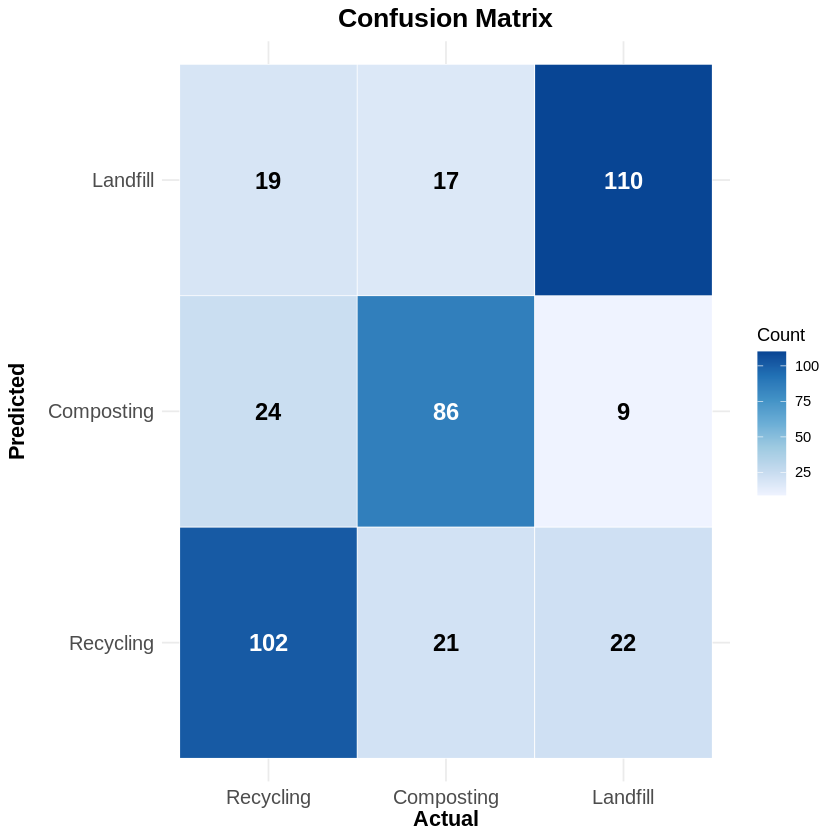

In [17]:
# Plotting the confusion matrix
ggplot(data = as.data.frame(conf_matrix_caret$table), aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "white") +
  scale_fill_distiller(palette = "Blues", direction = 1) +
  geom_text(aes(label = Freq, color = Freq > max(Freq)/2), vjust = 0.5, size = 5, fontface = "bold") +
  scale_color_manual(values = c("black", "white"), guide = "none") +
  theme_minimal() +
  labs(
    title = "Confusion Matrix",
    x = "Actual",
    y = "Predicted",
    fill = "Count"
  ) +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 13, face = "bold")
  )

### Likelihood Ratio Test

In [18]:
# Compare your model against a null model
null_model <- nnet::multinom(DisposalMethods ~ 1, data = working_data)
lrtest(null_model, model)

# weights:  6 (2 variable)
initial  value 450.431038 
final  value 449.507984 
converged


,#Df,LogLik,Df,Chisq,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2,-449.5080,NA,NA,NA
2,20,-261.6053,18,375.8054,9.991234e-69


### Pseudo-R squared tests

In [19]:
PseudoR2(model, which = c("McFadden", "Nagelkerke", "CoxSnell"))

McFadden Nagelkerke   CoxSnell 
 0.4180186  0.6755196  0.6001231

In [20]:
Anova(model, type = "III")

,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
UsingPlasticProducts,109.65838,6,2.403354e-21
SustainableBrands,21.15816,2,2.544281e-05
Location,10.98130,4,2.677494e-02
TransportationMode,51.96229,6,1.897665e-09


## Reference
- https://stats.oarc.ucla.edu/r/dae/multinomial-logistic-regression/
- https://statisticsbyjim.com/regression/multinomial-logistic-regression/
- https://rpubs.com/beane/n4_2